
# Kagome fRG sanity-check pipeline

This notebook builds a **standard spinful kagome model** using the corrected `channels.py` and `frg_flow.py`, then runs two benchmark interaction points inspired by the PRL phase diagram:

- **FM benchmark:** `U=6, V=0`
- **PI benchmark:** `U=0, V=10`

Target setup:
- no flux
- van Hove filling proxy: `mu = 0`
- `Npatch = 12`

The purpose is simple:

1. verify the corrected longitudinal channel construction in a full end-to-end pipeline  
2. check whether the final leading instability looks **FM-like** for large `U`  
3. check whether it looks **PI-like** for large `V`  

If the second case still does **not** show PI-like structure, the next place to inspect is likely:
- `form_factor.py`
- `kagome_order_diagnosis.py`

---


In [1]:

import sys
from pathlib import Path
from pprint import pprint
import numpy as np
import numpy as np
import matplotlib.pyplot as plt

# Make sure the uploaded modules are importable
sys.path.insert(0, "/mnt/data")

from noninteracting import KagomeNagaosa
from patching import FSPatcher, plot_patchset
from interaction import BareExtendedHubbard
from frg_flow import BareVertexFromInteraction, FRGFlowSolver



## 1. Global parameters

You can tune the flow resolution here.

Notes:
- `mu=0` matches the PRL convention for kagome VHF.
- `band_index=1` is the dispersive band crossing `mu=0` inside each 3x3 spin block.
- `Npatch=12` is intentionally small, just for a fast pipeline sanity check.
- For a more reliable final physics check, increase `Npatch`, `nfreq`, and `n_steps`.


In [2]:

# ---------- noninteracting / patching ----------
MODEL_PARAMS = dict(t=1.0, phi=0.0)   # standard kagome = phi=0
MU = 0.0
NPATCH = 6
GRID_SIZE = 220
CONTOUR_MIN_POINTS = 40

# Each spin block is 3x3 inside the full 6x6 spinful Hamiltonian
UP_SLICE = slice(0, 3)
DN_SLICE = slice(3, 6)
LOCAL_BAND_INDEX = 1   # dispersive band crossing mu=0

# ---------- flow ----------
FLOW_KWARGS = dict(
    T_start=1.5,
    T_stop=0.5,
    n_steps=200,
    nfreq=10,
    diagnose_every=10,
    temperature_grid="log",
    include_explicit_T_prefactor=True,
    max_relative_update=1,
    min_substep_fraction=0.1,
    channel_divergence_threshold=1e5,
    eigenvalue_threshold=1e5,
    diagnosis_sort_by="abs",
    track_crossed_channel=True,
    diagnosis_Qs = [np.array([0.0, 0.0]), np.pi * np.array([-0.5, -np.sqrt(3)/2]), np.pi * np.array([ 1.0,  0.0]), np.pi * np.array([-0.5,  np.sqrt(3)/2])]
)


## 2. Build the standard spinful kagome model and the two spin patchsets

In [3]:

model = KagomeNagaosa(MODEL_PARAMS, spin=True, B=None)

def build_patchsets(model, mu=0.0, npatch=12, grid_size=220, contour_min_points=40):
    patch_up = FSPatcher(
        model,
        band_index=LOCAL_BAND_INDEX,
        mu=mu,
        Npatch=npatch,
        grid_size=grid_size,
        orbital_slice=UP_SLICE,
        contour_min_points=contour_min_points,
        gauge_fix="parallel_transport",
        verbose=False,
        # auto_level_shifts = [0],
    ).build()

    patch_dn = FSPatcher(
        model,
        band_index=LOCAL_BAND_INDEX,
        mu=mu,
        Npatch=npatch,
        grid_size=grid_size,
        orbital_slice=DN_SLICE,
        contour_min_points=contour_min_points,
        gauge_fix="parallel_transport",
        verbose=False,
        # auto_level_shifts = [0],
    ).build()

    return {"up": patch_up, "dn": patch_dn}

patchsets = build_patchsets(
    model,
    mu=MU,
    npatch=NPATCH,
    grid_size=GRID_SIZE,
    contour_min_points=CONTOUR_MIN_POINTS,
)

print("Patch counts:", {k: v.Npatch for k, v in patchsets.items()})
print("mu used for contour (up/dn):", patchsets["up"].mu_used_for_contour, patchsets["dn"].mu_used_for_contour)
print("gauge loop phase (up/dn):", patchsets["up"].gauge_loop_phase, patchsets["dn"].gauge_loop_phase)


Patch counts: {'up': 6, 'dn': 6}
mu used for contour (up/dn): 0.0005 0.0005
gauge loop phase (up/dn): -1.2246467991473532e-16 -1.2246467991473532e-16


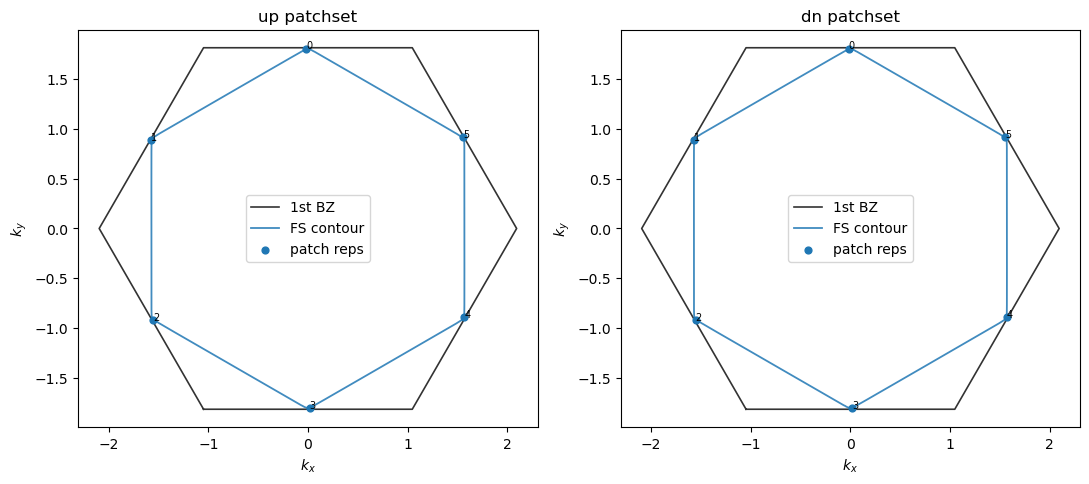

In [4]:

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
plot_patchset(patchsets["up"], ax=axes[0], show_contour=True, show_velocity=False, show_bz=True)
axes[0].set_title("up patchset")
plot_patchset(patchsets["dn"], ax=axes[1], show_contour=True, show_velocity=False, show_bz=True)
axes[1].set_title("dn patchset")
plt.tight_layout()
plt.show()


## 3. Helpers for running a benchmark interaction point

### Debug FRG Solver

In [5]:
from frg_flow import FRGFlowSolver

_old_step = FRGFlowSolver.step
_old_run = FRGFlowSolver.run

def _debug_step(self, T_old, dT):
    print(f"[DEBUG] entering step: T_old={T_old:.8f}, dT={dT:.8e}")
    try:
        rec = _old_step(self, T_old, dT)
        print(
            f"[DEBUG] leaving step: "
            f"T_new={getattr(rec, 'temperature', float(T_old + dT)):.8f}, "
            f"rhs_norm={getattr(rec, 'rhs_norm', None)}, "
            f"channel_norm={getattr(rec, 'channel_norm', None)}, "
            f"accepted_substeps={getattr(rec, 'accepted_substeps', None)}, "
            f"max_rel_update={getattr(rec, 'max_rel_update', None)}"
        )
        return rec
    except Exception as e:
        print(f"[DEBUG] exception in step:")
        print(f"        T_old = {T_old:.8f}")
        print(f"        dT    = {dT:.8e}")
        print(f"        T_new = {T_old + dT:.8f}")
        raise

def _debug_run(self):
    # print("[DEBUG] temperature path:")
    # for i, T in enumerate(self.temperature_path):
    #     print(f"  i={i:03d}, T={float(T):.8f}")
    return _old_run(self)

FRGFlowSolver.step = _debug_step
FRGFlowSolver.run = _debug_run

In [6]:
def build_solver(model, patchsets, U, V, flow_kwargs=None):
    flow_kwargs = {} if flow_kwargs is None else dict(flow_kwargs)
    interaction = BareExtendedHubbard.from_kagome_model(model, U=U, V=V)
    bare_gamma = BareVertexFromInteraction(interaction, patchsets)
    solver = FRGFlowSolver(
        patchsets=patchsets,
        bare_gamma=bare_gamma,
        **flow_kwargs,
    )
    return interaction, bare_gamma, solver


def summarize_history(history):
    rows = []
    for rec in history:
        rows.append({
            "step": rec.step_index,
            "T": rec.temperature,
            "channel_norm": rec.channel_norm,
            "rhs_norm": rec.rhs_norm,
            "leading_channel": rec.leading_channel_name,
            "leading_order": rec.leading_order_label,
            "leading_abs_eval": rec.leading_eigenvalue_abs,
            "instability": rec.instability,
            "reason": rec.instability_reason,
        })
    return rows


def pretty_print_final_record(history):
    rec = history[-1]
    print("===== Final record =====")
    pprint(rec.summary_dict())
    return rec


def plot_history(history, title):
    steps = [h.step_index for h in history]
    Ts = [h.temperature for h in history]
    evals = [np.nan if h.leading_eigenvalue_abs is None else h.leading_eigenvalue_abs for h in history]
    norms = [h.channel_norm for h in history]

    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    axes[0].plot(steps, evals, marker="o")
    axes[0].set_xlabel("step")
    axes[0].set_ylabel("leading |eigenvalue|")
    axes[0].set_title(f"{title}: leading eigenvalue")

    axes[1].plot(steps, norms, marker="o")
    axes[1].set_xlabel("step")
    axes[1].set_ylabel("channel norm")
    axes[1].set_title(f"{title}: channel norm")

    plt.tight_layout()
    plt.show()


def run_case(case_name, U, V, flow_kwargs=None):
    print(f"\n===== Running case: {case_name} (U={U}, V={V}) =====")
    interaction, bare_gamma, solver = build_solver(
        model=model,
        patchsets=patchsets,
        U=U,
        V=V,
        flow_kwargs=flow_kwargs if flow_kwargs is not None else FLOW_KWARGS,
    )
    history = solver.run()
    print(f"history length = {len(history)}")
    print(f"instability record = {None if solver.instability_record is None else solver.instability_record.step_index}")
    final_rec = pretty_print_final_record(history)
    plot_history(history, case_name)
    return {
        "case_name": case_name,
        "U": U,
        "V": V,
        "interaction": interaction,
        "solver": solver,
        "history": history,
        "final_record": final_rec,
    }



## 4. FM benchmark: `U=6, V=0`

Expectation from the PRL benchmark at van Hove filling:
- dominant onsite interaction should favor **ferromagnetism (FM)**.



===== Running case: FM benchmark (U=6.0, V=0.0) =====
[DEBUG] entering step: T_old=1.50000000, dT=-8.25818085e-03
[DEBUG] leaving step: T_new=1.49174182, rhs_norm=15.673445829869177, channel_norm=0.1294341502451542, accepted_substeps=1, max_rel_update=0.021584512526291184
[DEBUG] entering step: T_old=1.49174182, dT=-8.21271582e-03
[DEBUG] leaving step: T_new=1.48352910, rhs_norm=16.18913920557003, channel_norm=0.2623879501819052, accepted_substeps=1, max_rel_update=0.022171951543611304
[DEBUG] entering step: T_old=1.48352910, dT=-8.16750109e-03
[DEBUG] leaving step: T_new=1.47536160, rhs_norm=16.717105341268848, channel_norm=0.3989248462666475, accepted_substeps=1, max_rel_update=0.022768983806333125
[DEBUG] entering step: T_old=1.47536160, dT=-8.12253529e-03
[DEBUG] leaving step: T_new=1.46723907, rhs_norm=17.258086617416772, channel_norm=0.5391042635450822, accepted_substeps=1, max_rel_update=0.02337639941939326
[DEBUG] entering step: T_old=1.46723907, dT=-8.07781705e-03
[DEBUG] lea

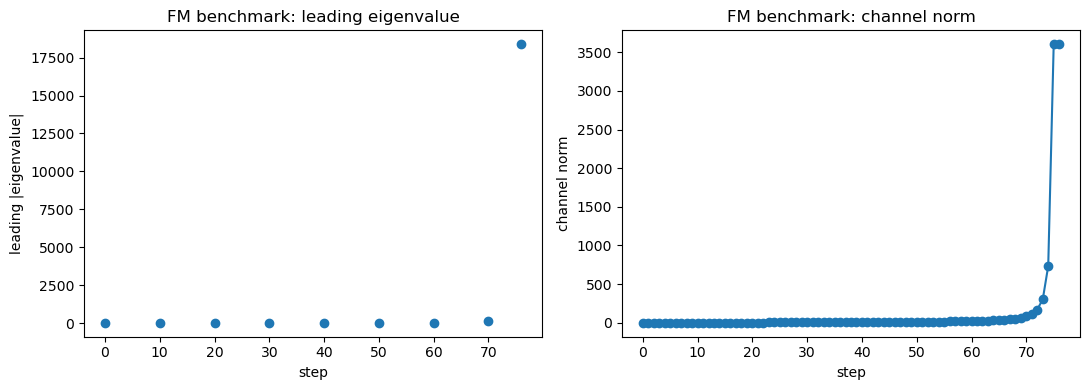

In [7]:

fm_result = run_case("FM benchmark", U=6.0, V=0.0, flow_kwargs=FLOW_KWARGS)



==== pp_singlet_sz0 ====
Q = [0. 0.]
|eig|max = 18379.174893856598
vec.real = [0.44094772 0.37267652 0.40828037 0.44093733 0.37266324 0.40826565]
vec.abs  = [0.44094772 0.37267652 0.40828037 0.44093733 0.37266324 0.40826565]

==== pp_triplet_sz0 ====
Q = [0. 0.]
|eig|max = 5888.053764214001
vec.real = [ 7.07111730e-01  1.55302902e-06  2.37187541e-04 -7.07101753e-01
 -1.55214591e-06 -2.37475159e-04]
vec.abs  = [7.07111730e-01 1.55302902e-06 2.37187541e-04 7.07101753e-01
 1.55214591e-06 2.37475159e-04]

==== ph_charge_longitudinal ====
Q = [0. 0.]
|eig|max = 10008.572110478563
vec.real = [-7.07060035e-01 -3.21832580e-04 -2.19984888e-04  7.07153310e-01
  3.21513864e-04  2.19953149e-04]
vec.abs  = [7.07060035e-01 3.21832580e-04 2.19984888e-04 7.07153310e-01
 3.21513864e-04 2.19953149e-04]

==== ph_spin_longitudinal ====
Q = [0. 0.]
|eig|max = 5900.842538485015
vec.real = [-7.07066422e-01 -3.75107687e-04  4.56785480e-04  7.07146644e-01
  3.75225156e-04 -4.57017143e-04]
vec.abs  = [7.070664

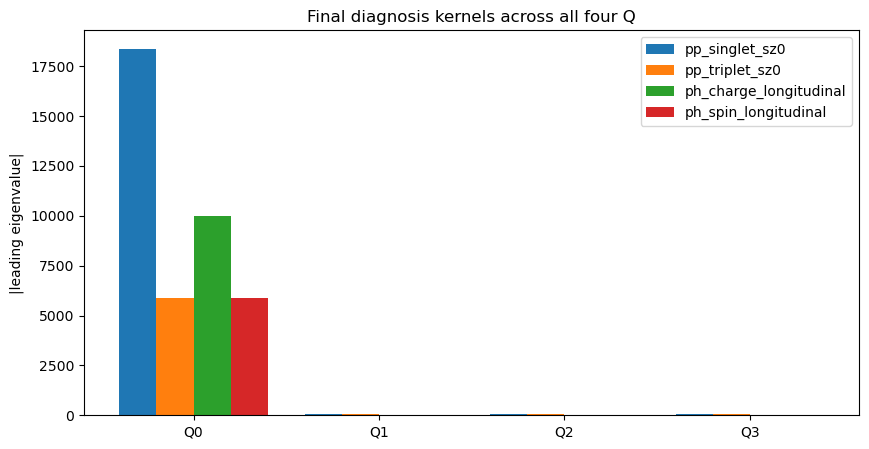


==== pp_singlet_sz0 ====
Q = [0. 0.]
|eig|max = 18379.174893856598
vec.real = [0.44094772 0.37267652 0.40828037 0.44093733 0.37266324 0.40826565]
vec.abs  = [0.44094772 0.37267652 0.40828037 0.44093733 0.37266324 0.40826565]

==== pp_triplet_sz0 ====
Q = [0. 0.]
|eig|max = 5888.053764214001
vec.real = [ 7.07111730e-01  1.55302902e-06  2.37187541e-04 -7.07101753e-01
 -1.55214591e-06 -2.37475159e-04]
vec.abs  = [7.07111730e-01 1.55302902e-06 2.37187541e-04 7.07101753e-01
 1.55214591e-06 2.37475159e-04]

==== ph_charge_longitudinal ====
Q = [0. 0.]
|eig|max = 10008.572110478563
vec.real = [-7.07060035e-01 -3.21832580e-04 -2.19984888e-04  7.07153310e-01
  3.21513864e-04  2.19953149e-04]
vec.abs  = [7.07060035e-01 3.21832580e-04 2.19984888e-04 7.07153310e-01
 3.21513864e-04 2.19953149e-04]

==== ph_spin_longitudinal ====
Q = [0. 0.]
|eig|max = 5900.842538485015
vec.real = [-7.07066422e-01 -3.75107687e-04  4.56785480e-04  7.07146644e-01
  3.75225156e-04 -4.57017143e-04]
vec.abs  = [7.070664

In [22]:

solver = fm_result["solver"]
Q = np.array([0.0, 0.0])
kernels = solver.build_diagnosis_kernel_dict(Q)
# for name, k in kernels.items():
#     vals, vecs = k.eig(sort_by="abs")
#     print(f"{name:25s}  |eig|max = {abs(vals[0]):.6g}")

for name in ["pp_singlet_sz0", "pp_triplet_sz0", "ph_charge_longitudinal", "ph_spin_longitudinal"]:
    k = kernels[name]
    vals, vecs = k.eig(sort_by="abs")
    print(f"\n==== {name} ====")
    print("Q =", k.Q)
    print("|eig|max =", abs(vals[0]))
    print("vec.real =", np.real(vecs[:, 0]))
    print("vec.abs  =", np.abs(vecs[:, 0]))

# 你现在 flow_kwargs 里已经有 diagnosis_Qs
Qs_to_check = FLOW_KWARGS["diagnosis_Qs"]

channels_to_check = [
    "pp_singlet_sz0",
    "pp_triplet_sz0",
    "ph_charge_longitudinal",
    "ph_spin_longitudinal",
]
solver = fm_result["solver"]
print("===== Final-state diagnosis across all Q =====")
for i, Q in enumerate(Qs_to_check):
    Q = np.asarray(Q, dtype=float)
    kernels = solver.build_diagnosis_kernel_dict(Q)

    print(f"\n===== Q[{i}] = {Q} =====")
    vals_dict = {}

    for name in channels_to_check:
        k = kernels[name]
        vals, vecs = k.eig(sort_by="abs")
        eigmax = abs(vals[0])
        vals_dict[name] = eigmax
        print(f"{name:26s} |eig|max = {eigmax:.8g}")

    lead_name = max(vals_dict, key=vals_dict.get)
    print(f"--> leading channel at this Q: {lead_name}  (|eig|max = {vals_dict[lead_name]:.8g})")
Q_summary = []

for i, Q in enumerate(Qs_to_check):
    Q = np.asarray(Q, dtype=float)
    kernels = solver.build_diagnosis_kernel_dict(Q)

    row = {
        "Q_index": i,
        "Q_vec": Q,
    }

    for name in channels_to_check:
        vals, _ = kernels[name].eig(sort_by="abs")
        row[name] = float(abs(vals[0]))

    row["leading_channel"] = max(channels_to_check, key=lambda name: row[name])
    row["leading_value"] = row[row["leading_channel"]]
    Q_summary.append(row)

Q_summary

import matplotlib.pyplot as plt
import numpy as np

labels = [f"Q{i}" for i in range(len(Q_summary))]
x = np.arange(len(labels))
width = 0.2

pp_s = [row["pp_singlet_sz0"] for row in Q_summary]
pp_t = [row["pp_triplet_sz0"] for row in Q_summary]
ph_c = [row["ph_charge_longitudinal"] for row in Q_summary]
ph_s = [row["ph_spin_longitudinal"] for row in Q_summary]

plt.figure(figsize=(10, 5))
plt.bar(x - 1.5*width, pp_s, width, label="pp_singlet_sz0")
plt.bar(x - 0.5*width, pp_t, width, label="pp_triplet_sz0")
plt.bar(x + 0.5*width, ph_c, width, label="ph_charge_longitudinal")
plt.bar(x + 1.5*width, ph_s, width, label="ph_spin_longitudinal")

plt.xticks(x, labels)
plt.ylabel("|leading eigenvalue|")
plt.title("Final diagnosis kernels across all four Q")
plt.legend()
plt.show()
# solver = fm_result["solver"]
Q = np.array([0.0, 0.0])
kernels = solver.build_diagnosis_kernel_dict(Q)
# for name, k in kernels.items():
#     vals, vecs = k.eig(sort_by="abs")
#     print(f"{name:25s}  |eig|max = {abs(vals[0]):.6g}")

for name in ["pp_singlet_sz0", "pp_triplet_sz0", "ph_charge_longitudinal", "ph_spin_longitudinal"]:
    k = kernels[name]
    vals, vecs = k.eig(sort_by="abs")
    print(f"\n==== {name} ====")
    print("Q =", k.Q)
    print("|eig|max =", abs(vals[0]))
    print("vec.real =", np.real(vecs[:, 0]))
    print("vec.abs  =", np.abs(vecs[:, 0]))

### Debug: Patch succeptibility

In [67]:
# ============================================================
# Patch-scaling test built on THIS notebook's actual pipeline
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from pprint import pprint

from noninteracting import KagomeNagaosa
from patching import FSPatcher
from interaction import BareExtendedHubbard
from frg_flow import BareVertexFromInteraction, FRGFlowSolver
from frg_kernel import FlowConfig, compute_pp_kernel_fast, compute_ph_kernel_fast
from channels import ChannelKernel


# ------------------------------------------------------------
# 0. Use notebook globals if they already exist; otherwise fallback
# ------------------------------------------------------------
try:
    MODEL_PARAMS
except NameError:
    MODEL_PARAMS = dict(t=1.0, phi=0.0)

try:
    MU
except NameError:
    MU = 0.0

try:
    GRID_SIZE
except NameError:
    GRID_SIZE = 220

try:
    CONTOUR_MIN_POINTS
except NameError:
    CONTOUR_MIN_POINTS = 40

try:
    UP_SLICE
except NameError:
    UP_SLICE = slice(0, 3)

try:
    DN_SLICE
except NameError:
    DN_SLICE = slice(3, 6)

try:
    LOCAL_BAND_INDEX
except NameError:
    LOCAL_BAND_INDEX = 1

try:
    FLOW_KWARGS
except NameError:
    FLOW_KWARGS = dict(
        T_start=1.5,
        T_stop=0.5,
        n_steps=200,
        nfreq=10,
        diagnose_every=10,
        temperature_grid="log",
        include_explicit_T_prefactor=True,
        max_relative_update=1,
        min_substep_fraction=0.1,
        channel_divergence_threshold=1e5,
        eigenvalue_threshold=1e5,
        diagnosis_sort_by="abs",
        track_crossed_channel=True,
        diagnosis_Qs=[
            np.array([0.0, 0.0]),
            np.pi * np.array([-0.5, -np.sqrt(3)/2]),
            np.pi * np.array([ 1.0,  0.0]),
            np.pi * np.array([-0.5,  np.sqrt(3)/2]),
        ],
    )


# ------------------------------------------------------------
# 1. Basic helpers
# ------------------------------------------------------------
def _leading_abs_eig(kernel, sort_by="abs"):
    vals, vecs = kernel.eig(sort_by=sort_by)
    return float(np.abs(vals[0])), vals[0], vecs[:, 0]


def _kernel_template_info(kernel, sort_by="abs"):
    lead_abs, lead_val, lead_vec = _leading_abs_eig(kernel, sort_by=sort_by)
    return {
        "leading_abs": lead_abs,
        "leading_val": lead_val,
        "leading_vec_real": np.real(lead_vec),
        "leading_vec_abs": np.abs(lead_vec),
    }


def _safe_ratio(num, den):
    den = float(den)
    if abs(den) < 1e-14:
        return np.nan
    return float(num) / den


# ------------------------------------------------------------
# 2. Build model / patchsets / solver exactly like your notebook
# ------------------------------------------------------------
def build_model():
    return KagomeNagaosa(MODEL_PARAMS, spin=True, B=None)


def build_patchsets_for_npatch(
    npatch,
    *,
    mu=MU,
    grid_size=GRID_SIZE,
    contour_min_points=CONTOUR_MIN_POINTS,
):
    model = build_model()

    patch_up = FSPatcher(
        model,
        band_index=LOCAL_BAND_INDEX,
        mu=mu,
        Npatch=npatch,
        grid_size=grid_size,
        orbital_slice=UP_SLICE,
        contour_min_points=contour_min_points,
        gauge_fix="parallel_transport",
        verbose=False,
    ).build()

    patch_dn = FSPatcher(
        model,
        band_index=LOCAL_BAND_INDEX,
        mu=mu,
        Npatch=npatch,
        grid_size=grid_size,
        orbital_slice=DN_SLICE,
        contour_min_points=contour_min_points,
        gauge_fix="parallel_transport",
        verbose=False,
    ).build()

    patchsets = {"up": patch_up, "dn": patch_dn}
    return model, patchsets


def build_interaction(model, U, V):
    return BareExtendedHubbard.from_kagome_model(model, U=U, V=V)


def build_solver_for_patchsets(model, patchsets, U, V, flow_kwargs=None):
    flow_kwargs = dict(FLOW_KWARGS if flow_kwargs is None else flow_kwargs)
    interaction = build_interaction(model, U, V)
    bare_gamma = BareVertexFromInteraction(interaction, patchsets)
    solver = FRGFlowSolver(
        patchsets=patchsets,
        bare_gamma=bare_gamma,
        **flow_kwargs,
    )
    return interaction, bare_gamma, solver


# ------------------------------------------------------------
# 3. Longitudinal / singlet combination helpers
#    (copied from your own notebook logic, but made reusable)
# ------------------------------------------------------------
def combine_pp_singlet_triplet(K_ud_ud, K_ud_du, K_du_ud, K_du_du, Q):
    singlet = 0.5 * (
        K_ud_ud.matrix - K_ud_du.matrix - K_du_ud.matrix + K_du_du.matrix
    )
    triplet = 0.5 * (
        K_ud_ud.matrix + K_ud_du.matrix + K_du_ud.matrix + K_du_du.matrix
    )

    template = K_ud_ud
    K_singlet = ChannelKernel(
        name="pp_singlet_sz0",
        Q=np.asarray(Q, dtype=float),
        matrix=np.asarray(singlet, dtype=complex),
        row_patches=template.row_patches.copy(),
        col_patches=template.col_patches.copy(),
        row_partner_patches=template.row_partner_patches.copy(),
        col_partner_patches=template.col_partner_patches.copy(),
        row_spins=("S", "S"),
        col_spins=("S", "S"),
        residuals=template.residuals.copy(),
    )
    K_triplet = ChannelKernel(
        name="pp_triplet_sz0",
        Q=np.asarray(Q, dtype=float),
        matrix=np.asarray(triplet, dtype=complex),
        row_patches=template.row_patches.copy(),
        col_patches=template.col_patches.copy(),
        row_partner_patches=template.row_partner_patches.copy(),
        col_partner_patches=template.col_partner_patches.copy(),
        row_spins=("T", "T"),
        col_spins=("T", "T"),
        residuals=template.residuals.copy(),
    )
    return K_singlet, K_triplet


def combine_ph_longitudinal(K_uu_uu, K_uu_dd, K_dd_uu, K_dd_dd, Q):
    charge = 0.5 * (
        K_uu_uu.matrix + K_uu_dd.matrix + K_dd_uu.matrix + K_dd_dd.matrix
    )
    spin = 0.5 * (
        K_uu_uu.matrix - K_uu_dd.matrix - K_dd_uu.matrix + K_dd_dd.matrix
    )

    residuals = np.maximum.reduce([
        K_uu_uu.residuals,
        K_uu_dd.residuals,
        K_dd_uu.residuals,
        K_dd_dd.residuals,
    ])

    template = K_uu_uu
    K_charge = ChannelKernel(
        name="ph_charge_longitudinal",
        Q=np.asarray(Q, dtype=float),
        matrix=np.asarray(charge, dtype=complex),
        row_patches=template.row_patches.copy(),
        col_patches=template.col_patches.copy(),
        row_partner_patches=template.row_partner_patches.copy(),
        col_partner_patches=template.col_partner_patches.copy(),
        row_spins=("rho", "rho"),
        col_spins=("rho", "rho"),
        residuals=np.asarray(residuals, dtype=float),
    )
    K_spin = ChannelKernel(
        name="ph_spin_longitudinal",
        Q=np.asarray(Q, dtype=float),
        matrix=np.asarray(spin, dtype=complex),
        row_patches=template.row_patches.copy(),
        col_patches=template.col_patches.copy(),
        row_partner_patches=template.row_partner_patches.copy(),
        col_partner_patches=template.col_partner_patches.copy(),
        row_spins=("sz", "sz"),
        col_spins=("sz", "sz"),
        residuals=np.asarray(residuals, dtype=float),
    )
    return K_charge, K_spin


# ------------------------------------------------------------
# 4. Bare RHS kernels at a given Q and T
# ------------------------------------------------------------
def build_bare_rhs_kernels_for_patchsets(patchsets, model, U, V, Q, T, flow_kwargs=None):
    interaction, bare_gamma, solver0 = build_solver_for_patchsets(
        model, patchsets, U, V, flow_kwargs=flow_kwargs
    )

    cfg = FlowConfig(
        temperature=float(T),
        nfreq=solver0.nfreq,
        include_explicit_T_prefactor=solver0.include_explicit_T_prefactor,
    )

    # ----- raw pp -----
    K_ud_ud = compute_pp_kernel_fast(
        bare_gamma, patchsets, Q,
        incoming_spins=("up", "dn"),
        outgoing_spins=("up", "dn"),
        config=cfg,
        allowed_spin_blocks=solver0.allowed_spin_blocks,
    )
    K_ud_du = compute_pp_kernel_fast(
        bare_gamma, patchsets, Q,
        incoming_spins=("up", "dn"),
        outgoing_spins=("dn", "up"),
        config=cfg,
        allowed_spin_blocks=solver0.allowed_spin_blocks,
    )
    K_du_ud = compute_pp_kernel_fast(
        bare_gamma, patchsets, Q,
        incoming_spins=("dn", "up"),
        outgoing_spins=("up", "dn"),
        config=cfg,
        allowed_spin_blocks=solver0.allowed_spin_blocks,
    )
    K_du_du = compute_pp_kernel_fast(
        bare_gamma, patchsets, Q,
        incoming_spins=("dn", "up"),
        outgoing_spins=("dn", "up"),
        config=cfg,
        allowed_spin_blocks=solver0.allowed_spin_blocks,
    )
    K_pp_singlet, K_pp_triplet = combine_pp_singlet_triplet(
        K_ud_ud, K_ud_du, K_du_ud, K_du_du, Q
    )

    # ----- raw longitudinal ph -----
    K_uu_uu = compute_ph_kernel_fast(
        bare_gamma, patchsets, Q,
        incoming_spins=("up", "up"),
        outgoing_spins=("up", "up"),
        config=cfg,
        allowed_spin_blocks=solver0.allowed_spin_blocks,
    )
    K_uu_dd = compute_ph_kernel_fast(
        bare_gamma, patchsets, Q,
        incoming_spins=("up", "up"),
        outgoing_spins=("dn", "dn"),
        config=cfg,
        allowed_spin_blocks=solver0.allowed_spin_blocks,
    )
    K_dd_uu = compute_ph_kernel_fast(
        bare_gamma, patchsets, Q,
        incoming_spins=("dn", "dn"),
        outgoing_spins=("up", "up"),
        config=cfg,
        allowed_spin_blocks=solver0.allowed_spin_blocks,
    )
    K_dd_dd = compute_ph_kernel_fast(
        bare_gamma, patchsets, Q,
        incoming_spins=("dn", "dn"),
        outgoing_spins=("dn", "dn"),
        config=cfg,
        allowed_spin_blocks=solver0.allowed_spin_blocks,
    )
    K_ph_charge, K_ph_spin = combine_ph_longitudinal(
        K_uu_uu, K_uu_dd, K_dd_uu, K_dd_dd, Q
    )

    kernels = {
        "rhs_pp_singlet_sz0": K_pp_singlet,
        "rhs_pp_triplet_sz0": K_pp_triplet,
        "rhs_ph_charge_longitudinal": K_ph_charge,
        "rhs_ph_spin_longitudinal": K_ph_spin,
        # raw blocks if later needed
        "rhs_pp_ud_to_ud": K_ud_ud,
        "rhs_pp_ud_to_du": K_ud_du,
        "rhs_pp_du_to_ud": K_du_ud,
        "rhs_pp_du_to_du": K_du_du,
        "rhs_ph_uu_to_uu": K_uu_uu,
        "rhs_ph_uu_to_dd": K_uu_dd,
        "rhs_ph_dd_to_uu": K_dd_uu,
        "rhs_ph_dd_to_dd": K_dd_dd,
    }

    return {
        "interaction": interaction,
        "bare_gamma": bare_gamma,
        "solver0": solver0,
        "Q": np.asarray(Q, dtype=float),
        "T": float(T),
        "kernels": kernels,
    }


# ------------------------------------------------------------
# 5. Stage evaluators
# ------------------------------------------------------------
def evaluate_bare_stage(solver, Qs):
    out = {}
    for Q in Qs:
        Qkey = tuple(np.round(Q, 8))
        kernels = solver.build_diagnosis_kernel_dict(np.asarray(Q, dtype=float))
        out[Qkey] = {
            "pp_singlet_sz0": _kernel_template_info(kernels["pp_singlet_sz0"]),
            "ph_charge_longitudinal": _kernel_template_info(kernels["ph_charge_longitudinal"]),
            "ph_spin_longitudinal": _kernel_template_info(kernels["ph_spin_longitudinal"]),
        }
    return out


def evaluate_rhs_stage(patchsets, model, U, V, Qs, T_rhs, flow_kwargs=None):
    out = {}
    for Q in Qs:
        Q = np.asarray(Q, dtype=float)
        Qkey = tuple(np.round(Q, 8))
        rhs = build_bare_rhs_kernels_for_patchsets(
            patchsets, model, U, V, Q=Q, T=T_rhs, flow_kwargs=flow_kwargs
        )
        kernels = rhs["kernels"]
        out[Qkey] = {
            "pp_singlet_sz0": _kernel_template_info(kernels["rhs_pp_singlet_sz0"]),
            "ph_charge_longitudinal": _kernel_template_info(kernels["rhs_ph_charge_longitudinal"]),
            "ph_spin_longitudinal": _kernel_template_info(kernels["rhs_ph_spin_longitudinal"]),
        }
    return out


def evaluate_flow_stage(solver, Qs):
    out = {}
    for Q in Qs:
        Qkey = tuple(np.round(Q, 8))
        kernels = solver.build_diagnosis_kernel_dict(np.asarray(Q, dtype=float))
        out[Qkey] = {
            "pp_singlet_sz0": _kernel_template_info(kernels["pp_singlet_sz0"]),
            "ph_charge_longitudinal": _kernel_template_info(kernels["ph_charge_longitudinal"]),
            "ph_spin_longitudinal": _kernel_template_info(kernels["ph_spin_longitudinal"]),
        }
    return out


# ------------------------------------------------------------
# 6. Q=0 extractor + metrics
# ------------------------------------------------------------
def summarize_stage_over_Q(stage_dict):
    keys = list(stage_dict.keys())
    q0_key = None
    for k in keys:
        if np.linalg.norm(np.array(k, dtype=float)) < 1e-8:
            q0_key = k
            break
    if q0_key is None:
        raise ValueError("No Q=0 entry found in stage_dict.")

    q0 = stage_dict[q0_key]
    others = {k: v for k, v in stage_dict.items() if k != q0_key}

    pp0 = q0["pp_singlet_sz0"]["leading_abs"]
    phc0 = q0["ph_charge_longitudinal"]["leading_abs"]
    phs0 = q0["ph_spin_longitudinal"]["leading_abs"]

    phs_max_nonzeroQ = np.nan
    if len(others) > 0:
        phs_max_nonzeroQ = max(v["ph_spin_longitudinal"]["leading_abs"] for v in others.values())

    return {
        "Q0_pp": pp0,
        "Q0_ph_charge": phc0,
        "Q0_ph_spin": phs0,
        "R_spin": _safe_ratio(phs0, pp0),
        "R_charge": _safe_ratio(phc0, pp0),
        "Q0_over_max_nonzeroQ_ph_spin": _safe_ratio(phs0, phs_max_nonzeroQ) if len(others) > 0 else np.nan,
        "full": stage_dict,
    }


# ------------------------------------------------------------
# 7. Main patch-scaling driver
# ------------------------------------------------------------
def run_patch_scaling_test(
    patch_list,
    *,
    U=6.0,
    V=0.0,
    Qs=None,
    flow_kwargs=None,
    run_flow=True,
    verbose=True,
):
    if Qs is None:
        Qs = list(FLOW_KWARGS["diagnosis_Qs"])
    if flow_kwargs is None:
        flow_kwargs = dict(FLOW_KWARGS)

    results = []

    for npatch in patch_list:
        if verbose:
            print(f"\n===== Npatch = {npatch} =====")

        model, patchsets = build_patchsets_for_npatch(
            npatch,
            mu=MU,
            grid_size=GRID_SIZE,
            contour_min_points=CONTOUR_MIN_POINTS,
        )

        if verbose:
            print("patch counts:", {k: v.Npatch for k, v in patchsets.items()})
            print(
                "mu_used_for_contour (up/dn):",
                patchsets["up"].mu_used_for_contour,
                patchsets["dn"].mu_used_for_contour,
            )

        interaction, bare_gamma, solver0 = build_solver_for_patchsets(
            model, patchsets, U, V, flow_kwargs=flow_kwargs
        )

        # ----- bare -----
        bare_full = evaluate_bare_stage(solver0, Qs)
        bare_summary = summarize_stage_over_Q(bare_full)

        # ----- RHS at initial T -----
        T_rhs = float(flow_kwargs["T_start"])
        rhs_full = evaluate_rhs_stage(
            patchsets, model, U, V, Qs, T_rhs=T_rhs, flow_kwargs=flow_kwargs
        )
        rhs_summary = summarize_stage_over_Q(rhs_full)

        # ----- flow -----
        flow_summary = None
        final_record = None
        solver = None
        if run_flow:
            interaction, bare_gamma, solver = build_solver_for_patchsets(
                model, patchsets, U, V, flow_kwargs=flow_kwargs
            )
            solver.run()
            flow_full = evaluate_flow_stage(solver, Qs)
            flow_summary = summarize_stage_over_Q(flow_full)
            final_record = solver.history[-1].summary_dict() if len(solver.history) else None

        row = {
            "Npatch": int(npatch),
            "patchsets": patchsets,
            "model": model,
            "interaction": interaction,
            "bare_solver": solver0,
            "flow_solver": solver,
            "bare": bare_summary,
            "rhs": rhs_summary,
            "flow": flow_summary,
            "final_record": final_record,
        }
        results.append(row)

        if verbose:
            print(
                f"[bare] R_spin={bare_summary['R_spin']:.6g}, "
                f"R_charge={bare_summary['R_charge']:.6g}, "
                f"Q0/maxQ(ph_spin)={bare_summary['Q0_over_max_nonzeroQ_ph_spin']:.6g}"
            )
            print(
                f"[rhs ] R_spin={rhs_summary['R_spin']:.6g}, "
                f"R_charge={rhs_summary['R_charge']:.6g}, "
                f"Q0/maxQ(ph_spin)={rhs_summary['Q0_over_max_nonzeroQ_ph_spin']:.6g}"
            )
            if flow_summary is not None:
                print(
                    f"[flow] R_spin={flow_summary['R_spin']:.6g}, "
                    f"R_charge={flow_summary['R_charge']:.6g}, "
                    f"Q0/maxQ(ph_spin)={flow_summary['Q0_over_max_nonzeroQ_ph_spin']:.6g}"
                )
                if final_record is not None:
                    print(
                        f"       final leading channel = {final_record.get('leading_channel_name', None)} | "
                        f"leading order = {final_record.get('leading_order_label', None)} | "
                        f"leading |eig| = {final_record.get('leading_eigenvalue_abs', None)}"
                    )

    return results


# ------------------------------------------------------------
# 8. Plot helper
# ------------------------------------------------------------
def plot_patch_scaling_results(results):
    N = [r["Npatch"] for r in results]

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    # --- ratios ---
    axes[0].plot(N, [r["bare"]["R_spin"] for r in results], "o-", label="bare: ph_spin / pp")
    axes[0].plot(N, [r["rhs"]["R_spin"] for r in results], "s-", label="rhs: ph_spin / pp")
    if results[0]["flow"] is not None:
        axes[0].plot(N, [r["flow"]["R_spin"] for r in results], "^-", label="flow: ph_spin / pp")
    axes[0].set_xlabel("Npatch")
    axes[0].set_ylabel("R_spin")
    axes[0].set_title("Spin / PP ratio")
    axes[0].grid(True)
    axes[0].legend()

    # --- charge ratios ---
    axes[1].plot(N, [r["bare"]["R_charge"] for r in results], "o-", label="bare: ph_charge / pp")
    axes[1].plot(N, [r["rhs"]["R_charge"] for r in results], "s-", label="rhs: ph_charge / pp")
    if results[0]["flow"] is not None:
        axes[1].plot(N, [r["flow"]["R_charge"] for r in results], "^-", label="flow: ph_charge / pp")
    axes[1].set_xlabel("Npatch")
    axes[1].set_ylabel("R_charge")
    axes[1].set_title("Charge / PP ratio")
    axes[1].grid(True)
    axes[1].legend()

    # --- Q=0 dominance in ph_spin ---
    axes[2].plot(N, [r["bare"]["Q0_over_max_nonzeroQ_ph_spin"] for r in results], "o-", label="bare")
    axes[2].plot(N, [r["rhs"]["Q0_over_max_nonzeroQ_ph_spin"] for r in results], "s-", label="rhs")
    if results[0]["flow"] is not None:
        axes[2].plot(N, [r["flow"]["Q0_over_max_nonzeroQ_ph_spin"] for r in results], "^-", label="flow")
    axes[2].axhline(1.0, ls="--", lw=1.0, color="gray")
    axes[2].set_xlabel("Npatch")
    axes[2].set_ylabel("Q0 / max(nonzero Q)")
    axes[2].set_title("Q=0 dominance of ph_spin")
    axes[2].grid(True)
    axes[2].legend()

    plt.tight_layout()
    plt.show()


# ------------------------------------------------------------
# 9. Compact table printer
# ------------------------------------------------------------
def print_patch_scaling_table(results):
    print("\n================ PATCH SCALING SUMMARY ================\n")
    header = (
        f"{'Np':>4s} | "
        f"{'bare Rspin':>12s} {'rhs Rspin':>12s} {'flow Rspin':>12s} | "
        f"{'bare Rchg':>12s} {'rhs Rchg':>12s} {'flow Rchg':>12s}"
    )
    print(header)
    print("-" * len(header))

    for r in results:
        npatch = r["Npatch"]
        flow_rspin = np.nan if r["flow"] is None else r["flow"]["R_spin"]
        flow_rchg = np.nan if r["flow"] is None else r["flow"]["R_charge"]

        print(
            f"{npatch:4d} | "
            f"{r['bare']['R_spin']:12.6g} {r['rhs']['R_spin']:12.6g} {flow_rspin:12.6g} | "
            f"{r['bare']['R_charge']:12.6g} {r['rhs']['R_charge']:12.6g} {flow_rchg:12.6g}"
        )

In [ ]:
# ==========================================
# Run the patch-scaling test for FM benchmark
# ==========================================

patch_list = [6, 12, 24]

results_patch_scaling = run_patch_scaling_test(
    patch_list,
    U=6.0,
    V=0.0,              # 若你想测最近那组参数，可改成 V=0.2
    Qs=FLOW_KWARGS["diagnosis_Qs"],
    flow_kwargs=FLOW_KWARGS,
    run_flow=True,      # 先直接全跑；若太慢可改 False
    verbose=True,
)

print_patch_scaling_table(results_patch_scaling)
plot_patch_scaling_results(results_patch_scaling)


# -------------------------------------------------
# Optional: inspect final flow record for each patch
# -------------------------------------------------
for row in results_patch_scaling:
    print(f"\n===== Final record | Npatch = {row['Npatch']} =====")
    pprint(row["final_record"])


===== Npatch = 6 =====
patch counts: {'up': 6, 'dn': 6}
mu_used_for_contour (up/dn): 0.0005 0.0005
[DEBUG] entering step: T_old=1.50000000, dT=-8.25818085e-03
[DEBUG] leaving step: T_new=1.49174182, rhs_norm=15.673445829869177, channel_norm=0.1294341502451542, accepted_substeps=1, max_rel_update=0.021584512526291184
[DEBUG] entering step: T_old=1.49174182, dT=-8.21271582e-03
[DEBUG] leaving step: T_new=1.48352910, rhs_norm=16.18913920557003, channel_norm=0.2623879501819052, accepted_substeps=1, max_rel_update=0.022171951543611304
[DEBUG] entering step: T_old=1.48352910, dT=-8.16750109e-03
[DEBUG] leaving step: T_new=1.47536160, rhs_norm=16.717105341268848, channel_norm=0.3989248462666475, accepted_substeps=1, max_rel_update=0.022768983806333125
[DEBUG] entering step: T_old=1.47536160, dT=-8.12253529e-03
[DEBUG] leaving step: T_new=1.46723907, rhs_norm=17.258086617416772, channel_norm=0.5391042635450822, accepted_substeps=1, max_rel_update=0.02337639941939326
[DEBUG] entering step: T_o

### Debug: Why pp is always dominant (ph isn't) check if the bare interaction is correctly constructed

In [11]:
from frg_flow import BareVertexFromInteraction, FRGFlowSolver
from frg_kernel import (
    FlowConfig,
    compute_pp_kernel_fast,
    compute_ph_kernel_fast,
)
from channels import ChannelKernel

def make_fresh_solver(U, V, flow_kwargs=None):
    """
    Fresh solver with zero channel corrections.
    Do NOT call .run(); this stays at the bare initial state.
    """
    flow_kwargs = dict(FLOW_KWARGS if flow_kwargs is None else flow_kwargs)
    interaction = BareExtendedHubbard.from_kagome_model(model, U=U, V=V)
    bare_gamma = BareVertexFromInteraction(interaction, patchsets)
    solver0 = FRGFlowSolver(
        patchsets=patchsets,
        bare_gamma=bare_gamma,
        **flow_kwargs,
    )
    return interaction, bare_gamma, solver0


def print_kernel_summary(kernels, names=None, sort_by="abs", show_vec=False):
    """
    kernels: dict[str, ChannelKernel]
    """
    if names is None:
        names = list(kernels.keys())

    for name in names:
        k = kernels[name]
        vals, vecs = k.eig(sort_by=sort_by)
        print(f"{name:25s} |eig|max = {abs(vals[0]):.6g}")
        if show_vec:
            print("  Q =", k.Q)
            print("  vec.real =", np.real(vecs[:, 0]))
            print("  vec.abs  =", np.abs(vecs[:, 0]))


def combine_pp_singlet_triplet(K_ud_ud, K_ud_du, K_du_ud, K_du_du, Q):
    """
    Build pp singlet/triplet from four raw mixed-spin pp blocks.
    """
    singlet = 0.5 * (K_ud_ud.matrix - K_ud_du.matrix - K_du_ud.matrix + K_du_du.matrix)
    triplet = 0.5 * (K_ud_ud.matrix + K_ud_du.matrix + K_du_ud.matrix + K_du_du.matrix)

    template = K_ud_ud
    K_singlet = ChannelKernel(
        name="pp_singlet_sz0",
        Q=np.asarray(Q, dtype=float),
        matrix=np.asarray(singlet, dtype=complex),
        row_patches=template.row_patches.copy(),
        col_patches=template.col_patches.copy(),
        row_partner_patches=template.row_partner_patches.copy(),
        col_partner_patches=template.col_partner_patches.copy(),
        row_spins=("S", "S"),
        col_spins=("S", "S"),
        residuals=template.residuals.copy(),
    )
    K_triplet = ChannelKernel(
        name="pp_triplet_sz0",
        Q=np.asarray(Q, dtype=float),
        matrix=np.asarray(triplet, dtype=complex),
        row_patches=template.row_patches.copy(),
        col_patches=template.col_patches.copy(),
        row_partner_patches=template.row_partner_patches.copy(),
        col_partner_patches=template.col_partner_patches.copy(),
        row_spins=("T", "T"),
        col_spins=("T", "T"),
        residuals=template.residuals.copy(),
    )
    return K_singlet, K_triplet


def combine_ph_longitudinal(K_uu_uu, K_uu_dd, K_dd_uu, K_dd_dd, Q):
    """
    Build longitudinal charge/spin from four raw ph blocks.
    """
    charge = 0.5 * (
        K_uu_uu.matrix + K_uu_dd.matrix + K_dd_uu.matrix + K_dd_dd.matrix
    )
    spin = 0.5 * (
        K_uu_uu.matrix - K_uu_dd.matrix - K_dd_uu.matrix + K_dd_dd.matrix
    )

    residuals = np.maximum.reduce([
        K_uu_uu.residuals,
        K_uu_dd.residuals,
        K_dd_uu.residuals,
        K_dd_dd.residuals,
    ])

    template = K_uu_uu
    K_charge = ChannelKernel(
        name="ph_charge_longitudinal",
        Q=np.asarray(Q, dtype=float),
        matrix=np.asarray(charge, dtype=complex),
        row_patches=template.row_patches.copy(),
        col_patches=template.col_patches.copy(),
        row_partner_patches=template.row_partner_patches.copy(),
        col_partner_patches=template.col_partner_patches.copy(),
        row_spins=("rho", "rho"),
        col_spins=("rho", "rho"),
        residuals=np.asarray(residuals, dtype=float),
    )
    K_spin = ChannelKernel(
        name="ph_spin_longitudinal",
        Q=np.asarray(Q, dtype=float),
        matrix=np.asarray(spin, dtype=complex),
        row_patches=template.row_patches.copy(),
        col_patches=template.col_patches.copy(),
        row_partner_patches=template.row_partner_patches.copy(),
        col_partner_patches=template.col_partner_patches.copy(),
        row_spins=("sz", "sz"),
        col_spins=("sz", "sz"),
        residuals=np.asarray(residuals, dtype=float),
    )
    return K_charge, K_spin


def build_bare_rhs_kernels(U, V, Q=None, T=None, flow_kwargs=None):
    """
    Compute the one-loop RHS kernels at the bare initial state only.
    This isolates the true early RG feedback object.
    """
    if Q is None:
        Q = np.array([0.0, 0.0], dtype=float)

    interaction, bare_gamma, solver0 = make_fresh_solver(U, V, flow_kwargs=flow_kwargs)

    T_use = solver0.T_start if T is None else float(T)
    cfg = FlowConfig(
        temperature=T_use,
        nfreq=solver0.nfreq,
        include_explicit_T_prefactor=solver0.include_explicit_T_prefactor,
    )

    # ----- raw pp mixed-spin blocks -----
    K_ud_ud = compute_pp_kernel_fast(
        bare_gamma, patchsets, Q,
        incoming_spins=("up", "dn"),
        outgoing_spins=("up", "dn"),
        config=cfg,
        allowed_spin_blocks=solver0.allowed_spin_blocks,
    )
    K_ud_du = compute_pp_kernel_fast(
        bare_gamma, patchsets, Q,
        incoming_spins=("up", "dn"),
        outgoing_spins=("dn", "up"),
        config=cfg,
        allowed_spin_blocks=solver0.allowed_spin_blocks,
    )
    K_du_ud = compute_pp_kernel_fast(
        bare_gamma, patchsets, Q,
        incoming_spins=("dn", "up"),
        outgoing_spins=("up", "dn"),
        config=cfg,
        allowed_spin_blocks=solver0.allowed_spin_blocks,
    )
    K_du_du = compute_pp_kernel_fast(
        bare_gamma, patchsets, Q,
        incoming_spins=("dn", "up"),
        outgoing_spins=("dn", "up"),
        config=cfg,
        allowed_spin_blocks=solver0.allowed_spin_blocks,
    )
    K_pp_singlet, K_pp_triplet = combine_pp_singlet_triplet(
        K_ud_ud, K_ud_du, K_du_ud, K_du_du, Q
    )

    # ----- raw longitudinal ph blocks -----
    K_uu_uu = compute_ph_kernel_fast(
        bare_gamma, patchsets, Q,
        incoming_spins=("up", "up"),
        outgoing_spins=("up", "up"),
        config=cfg,
        allowed_spin_blocks=solver0.allowed_spin_blocks,
    )
    K_uu_dd = compute_ph_kernel_fast(
        bare_gamma, patchsets, Q,
        incoming_spins=("up", "up"),
        outgoing_spins=("dn", "dn"),
        config=cfg,
        allowed_spin_blocks=solver0.allowed_spin_blocks,
    )
    K_dd_uu = compute_ph_kernel_fast(
        bare_gamma, patchsets, Q,
        incoming_spins=("dn", "dn"),
        outgoing_spins=("up", "up"),
        config=cfg,
        allowed_spin_blocks=solver0.allowed_spin_blocks,
    )
    K_dd_dd = compute_ph_kernel_fast(
        bare_gamma, patchsets, Q,
        incoming_spins=("dn", "dn"),
        outgoing_spins=("dn", "dn"),
        config=cfg,
        allowed_spin_blocks=solver0.allowed_spin_blocks,
    )
    K_ph_charge, K_ph_spin = combine_ph_longitudinal(
        K_uu_uu, K_uu_dd, K_dd_uu, K_dd_dd, Q
    )

    kernels = {
        # raw pp
        "rhs_pp_ud_to_ud": K_ud_ud,
        "rhs_pp_ud_to_du": K_ud_du,
        "rhs_pp_du_to_ud": K_du_ud,
        "rhs_pp_du_to_du": K_du_du,
        "rhs_pp_singlet_sz0": K_pp_singlet,
        "rhs_pp_triplet_sz0": K_pp_triplet,
        # raw ph
        "rhs_ph_uu_to_uu": K_uu_uu,
        "rhs_ph_uu_to_dd": K_uu_dd,
        "rhs_ph_dd_to_uu": K_dd_uu,
        "rhs_ph_dd_to_dd": K_dd_dd,
        "rhs_ph_charge_longitudinal": K_ph_charge,
        "rhs_ph_spin_longitudinal": K_ph_spin,
    }

    return {
        "interaction": interaction,
        "bare_gamma": bare_gamma,
        "solver0": solver0,
        "Q": np.asarray(Q, dtype=float),
        "T": T_use,
        "kernels": kernels,
    }

In [23]:
# ===== Test A: bare diagnosis object at step 0 =====
U_test, V_test = 6.0, 0.0
Q0 = np.array([0.0, 0.0], dtype=float)

interaction0, bare_gamma0, solver0 = make_fresh_solver(U_test, V_test, flow_kwargs=FLOW_KWARGS)

# IMPORTANT:
# solver0 has zero channel corrections, so this is the step-0 full-vertex diagnosis object
bare_diag_kernels = solver0.build_diagnosis_kernel_dict(Q0)

print("===== Bare diagnosis (step 0 full vertex) at Q=0 =====")
print_kernel_summary(
    bare_diag_kernels,
    names=[
        "pp_singlet_sz0",
        "pp_triplet_sz0",
        "ph_charge_longitudinal",
        "ph_spin_longitudinal",
    ],
    show_vec=True,
)

===== Bare diagnosis (step 0 full vertex) at Q=0 =====
pp_singlet_sz0            |eig|max = 24
  Q = [0. 0.]
  vec.real = [0.40929429 0.40603411 0.40940748 0.40929429 0.40603411 0.40940748]
  vec.abs  = [0.40929429 0.40603411 0.40940748 0.40929429 0.40603411 0.40940748]
pp_triplet_sz0            |eig|max = 0
  Q = [0. 0.]
  vec.real = [1. 0. 0. 0. 0. 0.]
  vec.abs  = [1. 0. 0. 0. 0. 0.]
ph_charge_longitudinal    |eig|max = 12
  Q = [0. 0.]
  vec.real = [0.40929361 0.40599535 0.40944661 0.40929376 0.40599518 0.40944661]
  vec.abs  = [0.40929361 0.40599535 0.40944661 0.40929376 0.40599518 0.40944661]
ph_spin_longitudinal      |eig|max = 12
  Q = [0. 0.]
  vec.real = [0.40929361 0.40599535 0.40944661 0.40929376 0.40599518 0.40944661]
  vec.abs  = [0.40929361 0.40599535 0.40944661 0.40929376 0.40599518 0.40944661]


In [24]:
# ===== Test B: bare one-loop RHS at initial T =====
rhs_test = build_bare_rhs_kernels(
    U=6.0,
    V=0.0,
    Q=np.array([0.0, 0.0], dtype=float),
    T=FLOW_KWARGS["T_start"],   # usually T_start = 2
    flow_kwargs=FLOW_KWARGS,
)

print(f"===== Bare RHS kernels at Q=0, T={rhs_test['T']:.6f} =====")
print_kernel_summary(
    rhs_test["kernels"],
    names=[
        "rhs_pp_singlet_sz0",
        "rhs_pp_triplet_sz0",
        "rhs_ph_charge_longitudinal",
        "rhs_ph_spin_longitudinal",
    ],
    show_vec=True,
)

===== Bare RHS kernels at Q=0, T=1.500000 =====
rhs_pp_singlet_sz0        |eig|max = 62.7627
  Q = [0. 0.]
  vec.real = [0.40929429 0.40603411 0.40940748 0.40929429 0.40603411 0.40940748]
  vec.abs  = [0.40929429 0.40603411 0.40940748 0.40929429 0.40603411 0.40940748]
rhs_pp_triplet_sz0        |eig|max = 0
  Q = [0. 0.]
  vec.real = [1. 0. 0. 0. 0. 0.]
  vec.abs  = [1. 0. 0. 0. 0. 0.]
rhs_ph_charge_longitudinal |eig|max = 31.3815
  Q = [0. 0.]
  vec.real = [0.40929361 0.40599535 0.40944661 0.40929376 0.40599518 0.40944661]
  vec.abs  = [0.40929361 0.40599535 0.40944661 0.40929376 0.40599518 0.40944661]
rhs_ph_spin_longitudinal  |eig|max = 31.3815
  Q = [0. 0.]
  vec.real = [0.40929361 0.40599535 0.40944661 0.40929376 0.40599518 0.40944661]
  vec.abs  = [0.40929361 0.40599535 0.40944661 0.40929376 0.40599518 0.40944661]


In [25]:
# ===== Compare step-0 diagnosis object vs true bare RHS =====
compare_names = [
    ("pp_singlet_sz0", "rhs_pp_singlet_sz0"),
    ("pp_triplet_sz0", "rhs_pp_triplet_sz0"),
    ("ph_charge_longitudinal", "rhs_ph_charge_longitudinal"),
    ("ph_spin_longitudinal", "rhs_ph_spin_longitudinal"),
]

print("===== Side-by-side comparison =====")
for name_diag, name_rhs in compare_names:
    kd = bare_diag_kernels[name_diag]
    kr = rhs_test["kernels"][name_rhs]

    vals_d, vecs_d = kd.eig(sort_by="abs")
    vals_r, vecs_r = kr.eig(sort_by="abs")

    print(f"\n--- {name_diag} ---")
    print(f"step-0 diagnosis |eig|max = {abs(vals_d[0]):.6g}")
    print(f"bare RHS         |eig|max = {abs(vals_r[0]):.6g}")
    print("diagnosis vec.real =", np.real(vecs_d[:, 0]))
    print("rhs vec.real      =", np.real(vecs_r[:, 0]))

===== Side-by-side comparison =====

--- pp_singlet_sz0 ---
step-0 diagnosis |eig|max = 24
bare RHS         |eig|max = 62.7627
diagnosis vec.real = [0.40929429 0.40603411 0.40940748 0.40929429 0.40603411 0.40940748]
rhs vec.real      = [0.40929429 0.40603411 0.40940748 0.40929429 0.40603411 0.40940748]

--- pp_triplet_sz0 ---
step-0 diagnosis |eig|max = 0
bare RHS         |eig|max = 0
diagnosis vec.real = [1. 0. 0. 0. 0. 0.]
rhs vec.real      = [1. 0. 0. 0. 0. 0.]

--- ph_charge_longitudinal ---
step-0 diagnosis |eig|max = 12
bare RHS         |eig|max = 31.3815
diagnosis vec.real = [0.40929361 0.40599535 0.40944661 0.40929376 0.40599518 0.40944661]
rhs vec.real      = [0.40929361 0.40599535 0.40944661 0.40929376 0.40599518 0.40944661]

--- ph_spin_longitudinal ---
step-0 diagnosis |eig|max = 12
bare RHS         |eig|max = 31.3815
diagnosis vec.real = [0.40929361 0.40599535 0.40944661 0.40929376 0.40599518 0.40944661]
rhs vec.real      = [0.40929361 0.40599535 0.40944661 0.40929376 0.40

In [26]:
# ===== Inspect the four raw longitudinal ph blocks directly =====
raw_ph_names = [
    "rhs_ph_uu_to_uu",
    "rhs_ph_uu_to_dd",
    "rhs_ph_dd_to_uu",
    "rhs_ph_dd_to_dd",
]

print("===== Raw longitudinal ph blocks (bare RHS) =====")
print_kernel_summary(
    rhs_test["kernels"],
    names=raw_ph_names,
    show_vec=True,
)

===== Raw longitudinal ph blocks (bare RHS) =====
rhs_ph_uu_to_uu           |eig|max = 31.3815
  Q = [0. 0.]
  vec.real = [0.40929361 0.40599535 0.40944661 0.40929376 0.40599518 0.40944661]
  vec.abs  = [0.40929361 0.40599535 0.40944661 0.40929376 0.40599518 0.40944661]
rhs_ph_uu_to_dd           |eig|max = 0
  Q = [0. 0.]
  vec.real = [1. 0. 0. 0. 0. 0.]
  vec.abs  = [1. 0. 0. 0. 0. 0.]
rhs_ph_dd_to_uu           |eig|max = 0
  Q = [0. 0.]
  vec.real = [1. 0. 0. 0. 0. 0.]
  vec.abs  = [1. 0. 0. 0. 0. 0.]
rhs_ph_dd_to_dd           |eig|max = 31.3815
  Q = [0. 0.]
  vec.real = [0.40929361 0.40599535 0.40944661 0.40929376 0.40599518 0.40944661]
  vec.abs  = [0.40929361 0.40599535 0.40944661 0.40929376 0.40599518 0.40944661]


### debug: check susceptibility

In [27]:
import numpy as np

# ------------------------------------------------------------
# Minimal Bethe-Salpeter / ladder test on top of diagnosis kernels
# ------------------------------------------------------------

def _patchset_for_spin_local(patchsets, spin):
    """Lightweight spin-key resolver, matching your code conventions."""
    if spin in patchsets:
        return patchsets[spin]
    aliases = {
        "up": ["up", "u", +1, "0"],
        "dn": ["dn", "down", "d", -1, "1"],
    }
    for key in aliases.get(spin, []):
        if key in patchsets:
            return patchsets[key]
    raise KeyError(f"Could not find patchset for spin={spin!r}")


def _matsubara_freqs(T, nfreq):
    n = np.arange(-nfreq, nfreq + 1, dtype=float)
    return (2.0 * n + 1.0) * np.pi * T


def _chi0_pp_patch(E1, E2, T, nfreq=256):
    """
    Cooper bubble:
        chi_pp = T sum_n G(iw,E1) G(-iw,E2)
    """
    w = _matsubara_freqs(T, nfreq)
    g1 = 1.0 / (1j * w - E1)
    g2 = 1.0 / (-1j * w - E2)
    return T * np.sum(g1 * g2)


def _chi0_ph_patch(E1, E2, T, nfreq=256):
    """
    Particle-hole bubble:
        chi_ph = - T sum_n G(iw,E1) G(iw,E2)

    The minus sign is the standard ph-loop sign convention.
    """
    w = _matsubara_freqs(T, nfreq)
    g1 = 1.0 / (1j * w - E1)
    g2 = 1.0 / (1j * w - E2)
    return -T * np.sum(g1 * g2)


def _physical_leg_spins_for_bs(kernel_name):
    """
    Map semantic kernel names to a concrete physical spin choice for chi0.

    For longitudinal charge/spin, in your SU(2)-symmetric benchmark,
    using ('up','up') is enough as the physical representative.
    """
    name = kernel_name.lower()
    if name in {"pp_singlet_sz0", "pp_triplet_sz0"}:
        return ("up", "dn"), "pp"
    if name in {"ph_charge_longitudinal", "ph_spin_longitudinal"}:
        return ("up", "up"), "ph"
    if name.startswith("pp"):
        return ("up", "dn"), "pp"
    return ("up", "up"), "ph"


def build_bs_matrix_from_kernel(kernel, patchsets, T, nfreq=256):
    """
    Build a minimal ladder / BS matrix:

        M = K @ diag(chi0)

    where K is the channel kernel in patch space and chi0 is the
    patch-resolved bubble on the incoming bilinear / pair.

    This is the simplest channel-comparison object.
    """
    (sA, sB), sector = _physical_leg_spins_for_bs(kernel.name)

    psA = _patchset_for_spin_local(patchsets, sA)
    psB = _patchset_for_spin_local(patchsets, sB)

    # incoming side bubble lives on the kernel columns
    N = len(kernel.col_patches)
    chi0 = np.zeros(N, dtype=complex)

    for pin in range(N):
        pA = int(kernel.col_patches[pin])
        pB = int(kernel.col_partner_patches[pin])

        E1 = float(psA.patches[pA].energy)
        E2 = float(psB.patches[pB].energy)

        if sector == "pp":
            chi0[pin] = _chi0_pp_patch(E1, E2, T, nfreq=nfreq)
        else:
            chi0[pin] = _chi0_ph_patch(E1, E2, T, nfreq=nfreq)

    M = np.asarray(kernel.matrix, dtype=complex) @ np.diag(chi0)
    return {
        "kernel_name": kernel.name,
        "sector": sector,
        "chi0": chi0,
        "matrix": M,
    }


def summarize_bs_matrix(bs_obj, sort_by="abs"):
    M = np.asarray(bs_obj["matrix"], dtype=complex)
    vals, vecs = np.linalg.eig(M)

    if sort_by == "abs":
        order = np.argsort(-np.abs(vals))
    elif sort_by == "real":
        order = np.argsort(-np.real(vals))
    else:
        raise ValueError("sort_by must be 'abs' or 'real'.")

    vals = vals[order]
    vecs = vecs[:, order]

    return {
        "kernel_name": bs_obj["kernel_name"],
        "sector": bs_obj["sector"],
        "eigvals": vals,
        "eigvecs": vecs,
        "leading_abs": float(np.abs(vals[0])) if len(vals) else 0.0,
        "leading_real": float(np.real(vals[0])) if len(vals) else 0.0,
        "chi0_mean_abs": float(np.mean(np.abs(bs_obj["chi0"]))),
        "chi0_max_abs": float(np.max(np.abs(bs_obj["chi0"]))),
    }


def print_bs_summary(bs_results, names=None, sort_by="abs", show_vec=True):
    if names is None:
        names = list(bs_results.keys())

    print("===== Minimal BS / ladder summary =====")
    for name in names:
        out = summarize_bs_matrix(bs_results[name], sort_by=sort_by)
        vals = out["eigvals"]
        vecs = out["eigvecs"]

        print(f"{name:26s} | |eig|max = {out['leading_abs']:.6g} | Re(eig0) = {out['leading_real']:.6g}")
        print(f"    chi0_mean_abs = {out['chi0_mean_abs']:.6g} | chi0_max_abs = {out['chi0_max_abs']:.6g}")
        if show_vec and len(vals):
            print(f"    vec.real = {np.real(vecs[:,0])}")
            print(f"    vec.abs  = {np.abs(vecs[:,0])}")
        print()

In [28]:
# ===== Test BS at step 0 (bare full-vertex object) =====

Q0 = np.array([0.0, 0.0], dtype=float)

interaction0, bare_gamma0, solver0 = make_fresh_solver(
    U=6.0,
    V=0.0,
    flow_kwargs=FLOW_KWARGS,
)

bare_kernels = solver0.build_diagnosis_kernel_dict(Q0)

bs_bare = {}
for name in [
    "pp_singlet_sz0",
    "pp_triplet_sz0",
    "ph_charge_longitudinal",
    "ph_spin_longitudinal",
]:
    bs_bare[name] = build_bs_matrix_from_kernel(
        bare_kernels[name],
        solver0.patchsets,
        T=FLOW_KWARGS["T_start"],
        nfreq=FLOW_KWARGS.get("nfreq", 128),
    )

print_bs_summary(
    bs_bare,
    names=[
        "pp_singlet_sz0",
        "pp_triplet_sz0",
        "ph_charge_longitudinal",
        "ph_spin_longitudinal",
    ],
    sort_by="abs",
    show_vec=True,
)

===== Minimal BS / ladder summary =====
pp_singlet_sz0             | |eig|max = 3.92268 | Re(eig0) = 3.92268
    chi0_mean_abs = 0.163445 | chi0_max_abs = 0.163445
    vec.real = [0.40929429 0.40603411 0.40940748 0.40929429 0.40603411 0.40940748]
    vec.abs  = [0.40929429 0.40603411 0.40940748 0.40929429 0.40603411 0.40940748]

pp_triplet_sz0             | |eig|max = 0 | Re(eig0) = 0
    chi0_mean_abs = 0.163445 | chi0_max_abs = 0.163445
    vec.real = [1. 0. 0. 0. 0. 0.]
    vec.abs  = [1. 0. 0. 0. 0. 0.]

ph_charge_longitudinal     | |eig|max = 1.96134 | Re(eig0) = -1.96134
    chi0_mean_abs = 0.163445 | chi0_max_abs = 0.163445
    vec.real = [0.40929361 0.40599535 0.40944661 0.40929376 0.40599518 0.40944661]
    vec.abs  = [0.40929361 0.40599535 0.40944661 0.40929376 0.40599518 0.40944661]

ph_spin_longitudinal       | |eig|max = 1.96134 | Re(eig0) = 1.96134
    chi0_mean_abs = 0.163445 | chi0_max_abs = 0.163445
    vec.real = [0.40929361 0.40599535 0.40944661 0.40929376 0.40599518

In [29]:
# ===== Test BS at current solver state =====

Q0 = np.array([0.0, 0.0], dtype=float)

current_kernels = solver.build_diagnosis_kernel_dict(Q0)
T_now = solver.state.T

bs_now = {}
for name in [
    "pp_singlet_sz0",
    "pp_triplet_sz0",
    "ph_charge_longitudinal",
    "ph_spin_longitudinal",
]:
    bs_now[name] = build_bs_matrix_from_kernel(
        current_kernels[name],
        solver.patchsets,
        T=T_now,
        nfreq=FLOW_KWARGS.get("nfreq", 128),
    )

print(f"Current flow temperature T = {T_now:.6f}")
print_bs_summary(
    bs_now,
    names=[
        "pp_singlet_sz0",
        "pp_triplet_sz0",
        "ph_charge_longitudinal",
        "ph_spin_longitudinal",
    ],
    sort_by="abs",
    show_vec=True,
)

Current flow temperature T = 0.991452
===== Minimal BS / ladder summary =====
pp_singlet_sz0             | |eig|max = 4544.83 | Re(eig0) = 4544.83
    chi0_mean_abs = 0.247282 | chi0_max_abs = 0.247282
    vec.real = [0.44094772 0.37267652 0.40828037 0.44093733 0.37266324 0.40826565]
    vec.abs  = [0.44094772 0.37267652 0.40828037 0.44093733 0.37266324 0.40826565]

pp_triplet_sz0             | |eig|max = 1456.01 | Re(eig0) = -1456.01
    chi0_mean_abs = 0.247282 | chi0_max_abs = 0.247282
    vec.real = [ 7.07111730e-01  1.55302908e-06  2.37187541e-04 -7.07101753e-01
 -1.55214597e-06 -2.37475159e-04]
    vec.abs  = [7.07111730e-01 1.55302908e-06 2.37187541e-04 7.07101753e-01
 1.55214597e-06 2.37475159e-04]

ph_charge_longitudinal     | |eig|max = 2474.94 | Re(eig0) = 2474.94
    chi0_mean_abs = 0.247282 | chi0_max_abs = 0.247282
    vec.real = [-7.07060035e-01 -3.21832580e-04 -2.19984888e-04  7.07153310e-01
  3.21513864e-04  2.19953149e-04]
    vec.abs  = [7.07060035e-01 3.21832580e-04

In [30]:
# ===== Side-by-side: raw kernel vs minimal BS =====

compare_names = [
    "pp_singlet_sz0",
    "pp_triplet_sz0",
    "ph_charge_longitudinal",
    "ph_spin_longitudinal",
]

print("===== Raw kernel vs minimal BS =====")
for name in compare_names:
    k = current_kernels[name]
    vals_raw, vecs_raw = k.eig(sort_by="abs")

    out_bs = summarize_bs_matrix(bs_now[name], sort_by="abs")
    vals_bs = out_bs["eigvals"]
    vecs_bs = out_bs["eigvecs"]

    print(f"--- {name} ---")
    print(f"raw kernel |eig|max = {abs(vals_raw[0]):.6g}")
    print(f"BS matrix  |eig|max = {abs(vals_bs[0]):.6g}")
    print(f"raw vec.real = {np.real(vecs_raw[:,0])}")
    print(f"BS  vec.real = {np.real(vecs_bs[:,0])}")
    print()

===== Raw kernel vs minimal BS =====
--- pp_singlet_sz0 ---
raw kernel |eig|max = 18379.2
BS matrix  |eig|max = 4544.83
raw vec.real = [0.44094772 0.37267652 0.40828037 0.44093733 0.37266324 0.40826565]
BS  vec.real = [0.44094772 0.37267652 0.40828037 0.44093733 0.37266324 0.40826565]

--- pp_triplet_sz0 ---
raw kernel |eig|max = 5888.05
BS matrix  |eig|max = 1456.01
raw vec.real = [ 7.07111730e-01  1.55302902e-06  2.37187541e-04 -7.07101753e-01
 -1.55214591e-06 -2.37475159e-04]
BS  vec.real = [ 7.07111730e-01  1.55302908e-06  2.37187541e-04 -7.07101753e-01
 -1.55214597e-06 -2.37475159e-04]

--- ph_charge_longitudinal ---
raw kernel |eig|max = 10008.6
BS matrix  |eig|max = 2474.94
raw vec.real = [-7.07060035e-01 -3.21832580e-04 -2.19984888e-04  7.07153310e-01
  3.21513864e-04  2.19953149e-04]
BS  vec.real = [-7.07060035e-01 -3.21832580e-04 -2.19984888e-04  7.07153310e-01
  3.21513864e-04  2.19953149e-04]

--- ph_spin_longitudinal ---
raw kernel |eig|max = 5900.84
BS matrix  |eig|max = 

### Debug: Temperature succesptbility

{'T': 3.0, 'pp': np.float64(15.690682548245466), 'ph_spin': np.float64(7.84537304844748), 'ph_charge': np.float64(7.84537304844748), 'ph_spin_over_pp': np.float64(0.50000202504414)}
{'T': 2.5, 'pp': np.float64(22.59458286947347), 'ph_spin': np.float64(11.297337189764367), 'ph_charge': np.float64(11.297337189764367), 'ph_spin_over_pp': np.float64(0.5000020250441398)}
{'T': 2.0, 'pp': np.float64(35.3040357335523), 'ph_spin': np.float64(17.652089359006837), 'ph_charge': np.float64(17.652089359006837), 'ph_spin_over_pp': np.float64(0.5000020250441403)}
{'T': 1.5, 'pp': np.float64(62.76273019298186), 'ph_spin': np.float64(31.38149219378992), 'ph_charge': np.float64(31.38149219378992), 'ph_spin_over_pp': np.float64(0.50000202504414)}
{'T': 1.2, 'pp': np.float64(98.06676592653406), 'ph_spin': np.float64(49.033581552796775), 'ph_charge': np.float64(49.033581552796775), 'ph_spin_over_pp': np.float64(0.5000020250441408)}
{'T': 1.0, 'pp': np.float64(141.2161429342092), 'ph_spin': np.float64(70.60

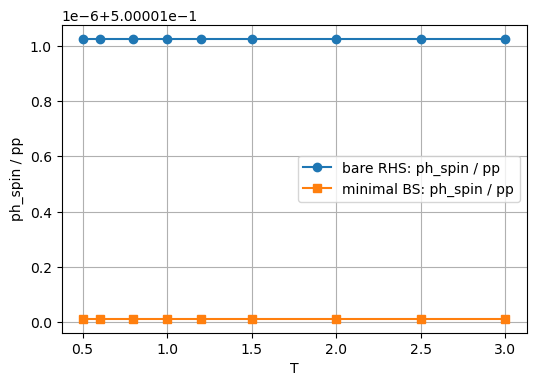

In [51]:
# # 生成 bs_scan
# T_list = [3.0, 2.5, 2.0, 1.5, 1.2, 1.0, 0.8, 0.6, 0.5]
# bs_scan = []
# for Ttest in T_list:
#     interaction0, bare_gamma0, solver0 = make_fresh_solver(
#         6.0, 0.0, flow_kwargs=FLOW_KWARGS
#     )
#     Q0 = np.array([0.0, 0.0], dtype=float)
#     bare_kernels = solver0.build_diagnosis_kernel_dict(Q0)

#     bs_tmp = {}
#     for name in [
#         "pp_singlet_sz0",
#         "pp_triplet_sz0",
#         "ph_charge_longitudinal",
#         "ph_spin_longitudinal",
#     ]:
#         bs_tmp[name] = build_bs_matrix_from_kernel(
#             bare_kernels[name],
#             solver0.patchsets,
#             T=Ttest,
#             nfreq=FLOW_KWARGS.get("nfreq", 128),
#         )

#     out_pp = summarize_bs_matrix(bs_tmp["pp_singlet_sz0"])
#     out_phs = summarize_bs_matrix(bs_tmp["ph_spin_longitudinal"])

#     bs_scan.append({
#         "T": Ttest,
#         "pp": out_pp["leading_abs"],
#         "ph_spin": out_phs["leading_abs"],
#         "ph_spin_over_pp": out_phs["leading_abs"] / out_pp["leading_abs"],
#     })



# rhs_scan = []

# for Ttest in T_list:
#     out = build_bare_rhs_kernels(
#         U=6.0,
#         V=0.0,
#         Q=np.array([0.0, 0.0], dtype=float),
#         T=Ttest,
#         flow_kwargs=FLOW_KWARGS,
#     )
#     kernels = out["kernels"]

#     vals_pp, _ = kernels["rhs_pp_singlet_sz0"].eig(sort_by="abs")
#     vals_phs, _ = kernels["rhs_ph_spin_longitudinal"].eig(sort_by="abs")
#     vals_phc, _ = kernels["rhs_ph_charge_longitudinal"].eig(sort_by="abs")

#     rhs_scan.append({
#         "T": Ttest,
#         "pp": abs(vals_pp[0]),
#         "ph_spin": abs(vals_phs[0]),
#         "ph_charge": abs(vals_phc[0]),
#         "ph_spin_over_pp": abs(vals_phs[0]) / abs(vals_pp[0]) if abs(vals_pp[0]) > 0 else np.nan,
#     })

# for row in rhs_scan:
#     print(row)
# import matplotlib.pyplot as plt

# Ts = [r["T"] for r in bs_scan]
# ratio_bs = [r["ph_spin_over_pp"] for r in bs_scan]

# Ts_rhs = [r["T"] for r in rhs_scan]
# ratio_rhs = [r["ph_spin_over_pp"] for r in rhs_scan]

# plt.figure(figsize=(6,4))
# plt.plot(Ts_rhs, ratio_rhs, "o-", label="bare RHS: ph_spin / pp")
# plt.plot(Ts, ratio_bs, "s-", label="minimal BS: ph_spin / pp")
# plt.xlabel("T")
# plt.ylabel("ph_spin / pp")
# plt.legend()
# plt.grid(True)
# plt.show()


## 5. PI benchmark: `U=0, V=10`

Expectation from the PRL benchmark at van Hove filling:
- dominant nearest-neighbor repulsion should favor **Pomeranchuk instability (PI)** with d-wave character.

If this still does **not** look PI-like, then the likely next suspects are:
- `form_factor.py`
- `kagome_order_diagnosis.py`



===== Running case: PI benchmark (U=0.0, V=10.0) =====
[DEBUG] entering step: T_old=1.50000000, dT=-8.25818085e-03
[DEBUG] leaving step: T_new=1.49174182, rhs_norm=696.9724413585882, channel_norm=5.7557244699580155, accepted_substeps=1, max_rel_update=0.28786388424232384
[DEBUG] entering step: T_old=1.49174182, dT=-8.21271582e-03
[DEBUG] leaving step: T_new=1.48352910, rhs_norm=923.3427371135338, channel_norm=13.33887597296559, accepted_substeps=1, max_rel_update=0.3792598929722047
[DEBUG] entering step: T_old=1.48352910, dT=-8.16750109e-03
[DEBUG] leaving step: T_new=1.47536160, rhs_norm=1477.11047447816, channel_norm=25.40317738357217, accepted_substeps=1, max_rel_update=0.6033778515378949
[DEBUG] entering step: T_old=1.47536160, dT=-8.12253529e-03
[DEBUG] leaving step: T_new=1.46723907, rhs_norm=2805.518158810966, channel_norm=48.191097633649264, accepted_substeps=1, max_rel_update=0.8970499991396226
[DEBUG] entering step: T_old=1.46723907, dT=-8.07781705e-03
[DEBUG] leaving step: 

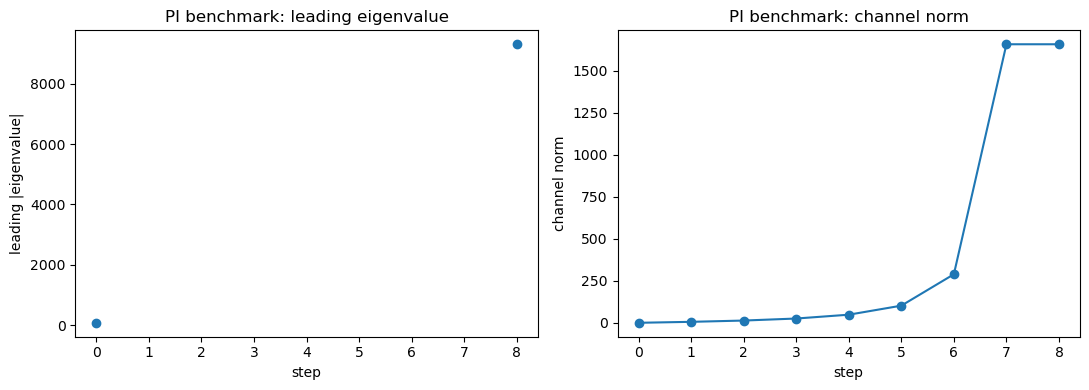

In [20]:

pi_result = run_case("PI benchmark", U=0.0, V=10.0, flow_kwargs=FLOW_KWARGS)



==== pp_singlet_sz0 ====
Q = [0. 0.]
|eig|max = 3555.149590780289
vec.real = [ 0.70723907 -0.00757092  0.00522446  0.70685552 -0.00804659  0.00433688]
vec.abs  = [0.70723907 0.00757092 0.00522446 0.70685552 0.00804659 0.00433688]

==== pp_triplet_sz0 ====
Q = [0. 0.]
|eig|max = 2990.372246504304
vec.real = [ 0.01255407 -0.63412549  0.30897717 -0.01064362  0.6378724  -0.30865172]
vec.abs  = [0.01255407 0.63412549 0.30897717 0.01064362 0.6378724  0.30865172]

==== ph_charge_longitudinal ====
Q = [0. 0.]
|eig|max = 5821.181048402714
vec.real = [0.37277506 0.44090947 0.4094923  0.37244863 0.43279804 0.41583834]
vec.abs  = [0.37277506 0.44090947 0.4094923  0.37244863 0.43279804 0.41583834]

==== ph_spin_longitudinal ====
Q = [0. 0.]
|eig|max = 8945.768270906441
vec.real = [0.39814162 0.42997657 0.40139207 0.390358   0.42031472 0.40797546]
vec.abs  = [0.39814162 0.42997657 0.40139207 0.390358   0.42031472 0.40797546]
===== Final-state diagnosis across all Q =====

===== Q[0] = [0. 0.] =====

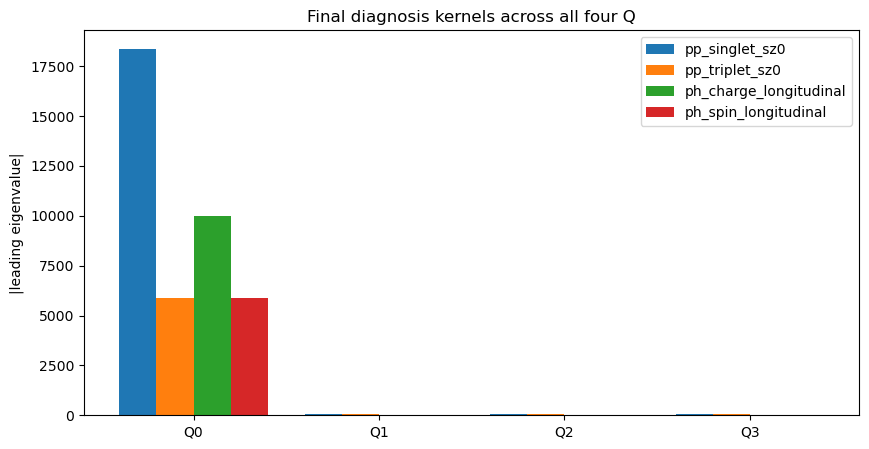


==== pp_singlet_sz0 ====
Q = [0. 0.]
|eig|max = 18379.174893856598
vec.real = [0.44094772 0.37267652 0.40828037 0.44093733 0.37266324 0.40826565]
vec.abs  = [0.44094772 0.37267652 0.40828037 0.44093733 0.37266324 0.40826565]

==== pp_triplet_sz0 ====
Q = [0. 0.]
|eig|max = 5888.053764214001
vec.real = [ 7.07111730e-01  1.55302902e-06  2.37187541e-04 -7.07101753e-01
 -1.55214591e-06 -2.37475159e-04]
vec.abs  = [7.07111730e-01 1.55302902e-06 2.37187541e-04 7.07101753e-01
 1.55214591e-06 2.37475159e-04]

==== ph_charge_longitudinal ====
Q = [0. 0.]
|eig|max = 10008.572110478563
vec.real = [-7.07060035e-01 -3.21832580e-04 -2.19984888e-04  7.07153310e-01
  3.21513864e-04  2.19953149e-04]
vec.abs  = [7.07060035e-01 3.21832580e-04 2.19984888e-04 7.07153310e-01
 3.21513864e-04 2.19953149e-04]

==== ph_spin_longitudinal ====
Q = [0. 0.]
|eig|max = 5900.842538485015
vec.real = [-7.07066422e-01 -3.75107687e-04  4.56785480e-04  7.07146644e-01
  3.75225156e-04 -4.57017143e-04]
vec.abs  = [7.070664

In [21]:

solver = pi_result["solver"]
Q = np.array([0.0, 0.0])
kernels = solver.build_diagnosis_kernel_dict(Q)
# for name, k in kernels.items():
#     vals, vecs = k.eig(sort_by="abs")
#     print(f"{name:25s}  |eig|max = {abs(vals[0]):.6g}")

for name in ["pp_singlet_sz0", "pp_triplet_sz0", "ph_charge_longitudinal", "ph_spin_longitudinal"]:
    k = kernels[name]
    vals, vecs = k.eig(sort_by="abs")
    print(f"\n==== {name} ====")
    print("Q =", k.Q)
    print("|eig|max =", abs(vals[0]))
    print("vec.real =", np.real(vecs[:, 0]))
    print("vec.abs  =", np.abs(vecs[:, 0]))

# 你现在 flow_kwargs 里已经有 diagnosis_Qs
Qs_to_check = FLOW_KWARGS["diagnosis_Qs"]

channels_to_check = [
    "pp_singlet_sz0",
    "pp_triplet_sz0",
    "ph_charge_longitudinal",
    "ph_spin_longitudinal",
]
solver = fm_result["solver"]
print("===== Final-state diagnosis across all Q =====")
for i, Q in enumerate(Qs_to_check):
    Q = np.asarray(Q, dtype=float)
    kernels = solver.build_diagnosis_kernel_dict(Q)

    print(f"\n===== Q[{i}] = {Q} =====")
    vals_dict = {}

    for name in channels_to_check:
        k = kernels[name]
        vals, vecs = k.eig(sort_by="abs")
        eigmax = abs(vals[0])
        vals_dict[name] = eigmax
        print(f"{name:26s} |eig|max = {eigmax:.8g}")

    lead_name = max(vals_dict, key=vals_dict.get)
    print(f"--> leading channel at this Q: {lead_name}  (|eig|max = {vals_dict[lead_name]:.8g})")
Q_summary = []

for i, Q in enumerate(Qs_to_check):
    Q = np.asarray(Q, dtype=float)
    kernels = solver.build_diagnosis_kernel_dict(Q)

    row = {
        "Q_index": i,
        "Q_vec": Q,
    }

    for name in channels_to_check:
        vals, _ = kernels[name].eig(sort_by="abs")
        row[name] = float(abs(vals[0]))

    row["leading_channel"] = max(channels_to_check, key=lambda name: row[name])
    row["leading_value"] = row[row["leading_channel"]]
    Q_summary.append(row)

Q_summary

import matplotlib.pyplot as plt
import numpy as np

labels = [f"Q{i}" for i in range(len(Q_summary))]
x = np.arange(len(labels))
width = 0.2

pp_s = [row["pp_singlet_sz0"] for row in Q_summary]
pp_t = [row["pp_triplet_sz0"] for row in Q_summary]
ph_c = [row["ph_charge_longitudinal"] for row in Q_summary]
ph_s = [row["ph_spin_longitudinal"] for row in Q_summary]

plt.figure(figsize=(10, 5))
plt.bar(x - 1.5*width, pp_s, width, label="pp_singlet_sz0")
plt.bar(x - 0.5*width, pp_t, width, label="pp_triplet_sz0")
plt.bar(x + 0.5*width, ph_c, width, label="ph_charge_longitudinal")
plt.bar(x + 1.5*width, ph_s, width, label="ph_spin_longitudinal")

plt.xticks(x, labels)
plt.ylabel("|leading eigenvalue|")
plt.title("Final diagnosis kernels across all four Q")
plt.legend()
plt.show()
# solver = fm_result["solver"]
Q = np.array([0.0, 0.0])
kernels = solver.build_diagnosis_kernel_dict(Q)
# for name, k in kernels.items():
#     vals, vecs = k.eig(sort_by="abs")
#     print(f"{name:25s}  |eig|max = {abs(vals[0]):.6g}")

for name in ["pp_singlet_sz0", "pp_triplet_sz0", "ph_charge_longitudinal", "ph_spin_longitudinal"]:
    k = kernels[name]
    vals, vecs = k.eig(sort_by="abs")
    print(f"\n==== {name} ====")
    print("Q =", k.Q)
    print("|eig|max =", abs(vals[0]))
    print("vec.real =", np.real(vecs[:, 0]))
    print("vec.abs  =", np.abs(vecs[:, 0]))

## 6. Compact side-by-side summary

In [ ]:

def compact_case_summary(result):
    rec = result["final_record"]
    return {
        "case": result["case_name"],
        "U": result["U"],
        "V": result["V"],
        "leading_channel": rec.leading_channel_name,
        "leading_order": rec.leading_order_label,
        "leading_abs_eval": rec.leading_eigenvalue_abs,
        "channel_norm": rec.channel_norm,
        "instability": rec.instability,
        "instability_reason": rec.instability_reason,
    }

summary = [
    compact_case_summary(fm_result),
    compact_case_summary(pi_result),
]

for row in summary:
    pprint(row)



## 7. Optional: inspect the raw diagnosis payloads

This is useful when:
- the FM case is reasonable but the PI case is not
- or the final `leading_order_label` is too coarse / ambiguous


In [ ]:

print("===== FM diagnosis payload =====")
pprint(fm_result["final_record"].diagnosis_payload)

print("\n===== PI diagnosis payload =====")
pprint(pi_result["final_record"].diagnosis_payload)



## 8. What to conclude from the outcomes

### If you get:
- `U=6, V=0` → FM-like
- `U=0, V=10` → PI-like

then the corrected `channels.py` + `frg_flow.py` have likely fixed the main bug, and the whole pipeline is much closer to the target PRL behavior.

### If you get:
- FM benchmark looks reasonable
- PI benchmark still does **not** become PI-like

then the next things to debug are likely:
1. **form-factor projection**
2. **PI degeneracy handling**
3. **kagome-specific diagnosis templates**

and only after that would I go back and seriously suspect the one-loop kernel again.
